# **Crossing Detector Data**
TODO: Make a general data loading script

In [6]:
from glob import glob
import os

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib widget
plt.close('all')

**Data**\
change folder and suffix

In [7]:
folder = 'C:\\Users\\Leah\\Documents\\OnixData\\CrossingDetectorTesting\\Test_Script_Crossing_Detector2\\Latency_Test1\\'

suffix = '0'

**Metadata**

In [8]:
dtMeta = {'names': ('time', 'acq_clk_hz', 'block_read_sz', 'block_write_sz'),
      'formats': ('datetime64[us]', 'u4', 'u4', 'u4')}
meta = np.genfromtxt(folder + 'start-time_' + suffix + '.csv', delimiter=',', dtype=dtMeta)
print(f"Recording was started at {meta['time']} GMT")

Recording was started at 2025-06-05T20:39:17.525299 GMT


**Analog Inputs**

In [9]:
analog_input = {}
analog_input['time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64) / meta['acq_clk_hz']
analog_input['raw_time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64)
analog_input['data'] = np.reshape(np.fromfile(folder + 'analog-data_' + suffix + '.raw', dtype=np.float32), (-1, 12))

**Crossing Detector TTL Out**

In [ ]:
# For csv directly from Crossing Detector
dtTTL = {'names': ('time', 'word_out'),
      'formats': ('datetime64[us]', 'u4')}
ttl = np.genfromtxt(folder + 'TTL-time_' + suffix + '.csv', delimiter=',', dtype=dtTTL)
print(f"First TTL out was at {ttl['time'][0]} GMT and was {ttl['word_out'][0]}")

# For csv from digital input


**Utility Functions**

In [7]:
def edge(data, thresh, edge):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == edge)
    return pos

**Plots**

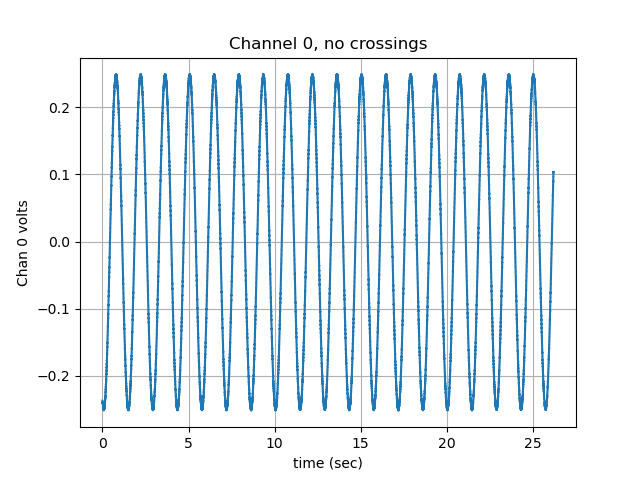

In [8]:
# Raw data plot
#min_len = min(len(analog_input['time']), analog_input['data'].shape[0])
analog_time = analog_input['time']#[:min_len]
channel_0 = analog_input['data'][:,0]#[:min_len, 0]

plt.figure()
plt.title("Channel 0, no crossings")
plt.plot(analog_time, channel_0)
plt.xlabel("time (sec)")
plt.ylabel("Chan 0 volts")
plt.grid(True)
plt.show()


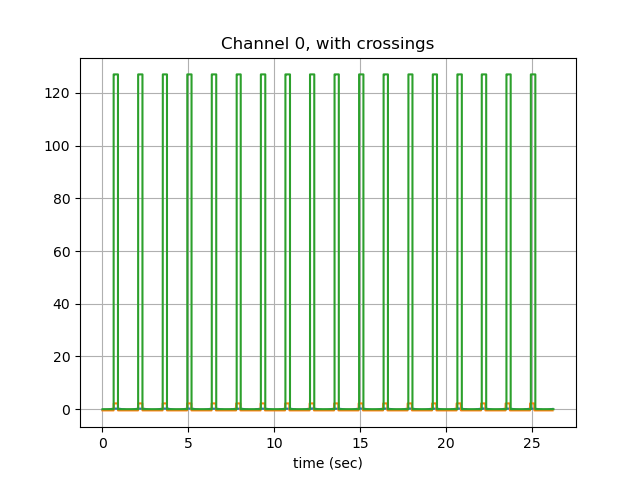

In [9]:
# Z score crossing 
sync_time = (ttl['time']) - (meta['time'])
ttl_time = sync_time.astype(np.double, casting='unsafe') / 1e6

# min_len_ttl = min(len(s), len(ttl['word_out']))
# s = s[:min_len_ttl]
word_out = ttl['word_out']#[:min_len_ttl]
z_word_out = stats.zscore(word_out)

plt.figure()
plt.title("Channel 0, with crossings")
plt.plot(analog_time, channel_0)
plt.plot(analog_time, z_word_out)
plt.plot(ttl_time, word_out)
plt.xlabel("time (sec)")
plt.grid(True)
plt.show()

In [10]:
print(ttl_time[1] - ttl_time[0])

0.0


In [11]:

# TLL word latencies 
rising_edge = edge(z_word_out,1,1)
falling_edge = edge(z_word_out,1,-1)

rising_time_stamp = ttl_time[rising_edge]
falling_time_stamp = ttl_time[falling_edge]

rising_time_stamp_dif = rising_time_stamp[1:] - rising_time_stamp[:-1]
falling_time_stamp_dif = falling_time_stamp[1:] - falling_time_stamp[:-1]

# Using TTL timestamps
print("rising and falling times in seconds from timestamps")
print(rising_time_stamp_dif)
print(falling_time_stamp_dif)

# Alligned to analog time
rising_time_analog = analog_time[rising_edge]
falling_time_analog = analog_time[falling_edge]

rising_time_analog_dif = rising_time_analog[1:] - rising_time_analog[:-1]
falling_time_analog_dif = falling_time_analog[1:] - falling_time_analog[:-1]

print("\nrising and falling times in seconds alligned to analog time")
print(rising_time_analog_dif)
print(falling_time_analog_dif)

# TTL timestamp duration
ttl_dur_stamps = falling_time_stamp - rising_time_stamp
ttl_dur_analog = falling_time_analog - rising_time_analog

print("\nTTL durations with respect to timestamps and analog time")
print(ttl_dur_stamps)
print(ttl_dur_analog)

rising and falling times in seconds from timestamps
[1.426035 1.431334 1.429607 1.425676 1.448858 1.408525 1.428569 1.43168
 1.428506 1.42784  1.427046 1.438567 1.424819 1.431014 1.419866 1.435866
 1.421696]
[1.425383 1.427584 1.429081 1.43744  1.42514  1.429964 1.438234 1.413133
 1.428569 1.431936 1.427226 1.427443 1.428442 1.445491 1.418381 1.424973
 1.435161]

rising and falling times in seconds alligned to analog time
[1.42344002 1.42596    1.42579999 1.42582    1.42631    1.42588
 1.42586    1.42613    1.42576    1.42601002 1.42598    1.42589
 1.42604    1.4257     1.42605001 1.42591999 1.42535   ]
[1.42344    1.42596    1.4258     1.42581999 1.42631    1.42588002
 1.42586    1.42612999 1.42576    1.42601    1.42597999 1.42589
 1.42604001 1.4257     1.42605    1.42591999 1.42535001]

TTL durations with respect to timestamps and analog time
[0.252108 0.251456 0.247706 0.24718  0.258944 0.235226 0.256665 0.26633
 0.247783 0.247846 0.251942 0.252122 0.240998 0.244621 0.259098 0.25761

C:\Users\Leah\AppData\Local\Temp\ipykernel_28860\3481549127.py:3: RuntimeWarning: divide by zero encountered in true_divide
  srate = 1/timeDif


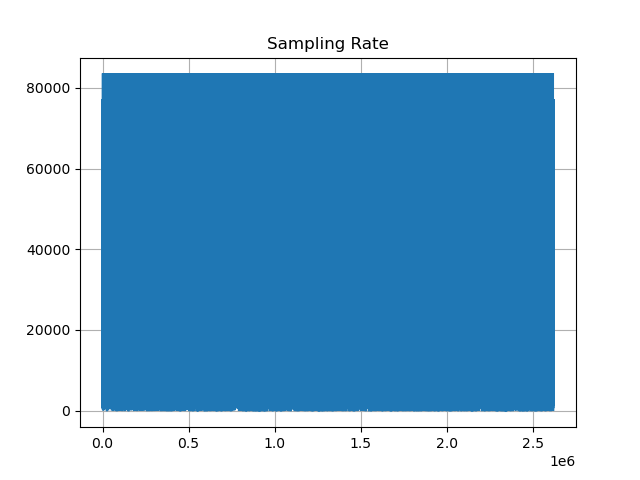

In [12]:
# Sampling Rate
timeDif = ttl_time[1:] - ttl_time[:-1]
srate = 1/timeDif

plt.figure()
plt.title("Sampling Rate")
plt.plot(srate)
plt.grid(True)
plt.show()